In [1]:
pip install pandas numpy matplotlib seaborn nltk wordcloud scikit-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [3]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
import pandas as pd

data = {
    "Review_ID": [1,2,3,4,5,6,7,8,9,10],

    "Customer_Name": [
        "Rahul","Priya","Arjun","Sneha","Kiran",
        "Ananya","Rohan","Meera","Varun","Divya"
    ],

    "Age": [24,28,31,22,35,27,30,26,29,23],

    "Gender": [
        "Male","Female","Male","Female","Male",
        "Female","Male","Female","Male","Female"
    ],

    "Restaurant_Name": [
        "Spice Hub","Pizza Town","Food Palace","Burger Spot",
        "Green Bowl","Coffee Corner","Tasty Treat",
        "Sushi World","Grill House","Sweet Treats"
    ],

    "Location": [
        "Bangalore","Mysore","Chennai","Bangalore","Hyderabad",
        "Pune","Delhi","Mumbai","Kochi","Bangalore"
    ],

    "Cuisine_Type": [
        "Indian","Italian","Chinese","Fast Food","Healthy",
        "Cafe","Indian","Japanese","BBQ","Dessert"
    ],

    "Food_Item": [
        "Biryani","Pizza","Noodles","Burger","Salad",
        "Coffee","Meals","Sushi","Chicken Grill","Cake"
    ],

    "Order_Type": [
        "Dine-in","Delivery","Takeaway","Delivery","Dine-in",
        "Dine-in","Delivery","Dine-in","Takeaway","Delivery"
    ],

    "Visit_Date": [
        "2026-01-05","2026-01-07","2026-01-10",
        "2026-01-12","2026-01-15","2026-01-18",
        "2026-01-20","2026-01-22","2026-01-25",
        "2026-01-28"
    ],

    "Rating": [5,2,4,1,5,4,3,5,2,5],

    "Review_Text": [
        "Food was delicious and service was excellent",
        "Pizza arrived late and was cold",
        "Good taste but waiting time was high",
        "Bad packaging and poor food quality",
        "Fresh food and peaceful environment",
        "Nice coffee but prices are expensive",
        "Food was okay but delivery was slow",
        "Amazing taste and great ambience",
        "Food quantity was less for the price",
        "Cake was fresh and delivered quickly"
    ],

    "Food_Quality": [
        "Excellent","Poor","Good","Poor","Excellent",
        "Good","Average","Excellent","Average","Excellent"
    ],

    "Taste": [
        "Spicy","Average","Delicious","Bad","Fresh",
        "Good","Average","Amazing","Good","Sweet"
    ],

    "Service_Rating": [5,2,3,1,5,4,3,5,2,5],

    "Staff_Behavior": [
        "Friendly","Average","Polite","Rude","Friendly",
        "Polite","Good","Friendly","Average","Friendly"
    ],

    "Cleanliness": [
        "Excellent","Good","Good","Average","Excellent",
        "Good","Good","Excellent","Good","Excellent"
    ],

    "Ambience": [
        "Good","NA","Average","NA","Excellent",
        "Good","NA","Excellent","Average","NA"
    ],

    "Waiting_Time_Min": [
        10,0,35,0,5,15,0,8,20,0
    ],

    "Price_Range": [
        "Medium","High","Medium","Low","High",
        "High","Medium","High","High","Medium"
    ],

    "Payment_Method": [
        "UPI","Card","Cash","UPI","Card",
        "UPI","Cash","Card","UPI","UPI"
    ],

    "Discount_Used": [
        "Yes","No","Yes","No","Yes",
        "No","No","Yes","No","Yes"
    ],

    "Delivery_Time_Min": [
        0,60,0,45,0,0,50,0,0,20
    ],

    "Delivery_Experience": [
        "NA","Poor","NA","Poor","NA",
        "NA","Average","NA","NA","Excellent"
    ],

    "Sentiment": [
        "Positive","Negative","Positive","Negative",
        "Positive","Positive","Neutral",
        "Positive","Negative","Positive"
    ],

    "Complaint_Type": [
        "None","Late Delivery","Waiting Time",
        "Food Quality","None","Price",
        "Delivery Delay","None","Quantity","None"
    ],

    "Recommended": [
        "Yes","No","Yes","No","Yes",
        "Yes","Yes","Yes","No","Yes"
    ],

    "Review_Length": [
        45,35,40,38,42,39,37,36,41,34
    ],

    "Customer_Type": [
        "Regular","New","Regular","New","Regular",
        "Regular","New","Regular","New","Regular"
    ],

    "Feedback_Source": [
        "App","Website","Google","App","Website",
        "Google","App","Website","Google","App"
    ]
}


df = pd.DataFrame(data)

print(df)

df.to_csv("Restaurant_Reviews.csv", index=False)

   Review_ID Customer_Name  Age  Gender Restaurant_Name   Location  \
0          1         Rahul   24    Male       Spice Hub  Bangalore   
1          2         Priya   28  Female      Pizza Town     Mysore   
2          3         Arjun   31    Male     Food Palace    Chennai   
3          4         Sneha   22  Female     Burger Spot  Bangalore   
4          5         Kiran   35    Male      Green Bowl  Hyderabad   
5          6        Ananya   27  Female   Coffee Corner       Pune   
6          7         Rohan   30    Male     Tasty Treat      Delhi   
7          8         Meera   26  Female     Sushi World     Mumbai   
8          9         Varun   29    Male     Grill House      Kochi   
9         10         Divya   23  Female    Sweet Treats  Bangalore   

  Cuisine_Type      Food_Item Order_Type  Visit_Date  ...  Payment_Method  \
0       Indian        Biryani    Dine-in  2026-01-05  ...             UPI   
1      Italian          Pizza   Delivery  2026-01-07  ...            Card  

In [5]:
df.head()

,Review_ID,Customer_Name,Age,Gender,Restaurant_Name,Location,Cuisine_Type,Food_Item,Order_Type,Visit_Date,...,Payment_Method,Discount_Used,Delivery_Time_Min,Delivery_Experience,Sentiment,Complaint_Type,Recommended,Review_Length,Customer_Type,Feedback_Source
0,1,Rahul,24,Male,Spice Hub,Bangalore,Indian,Biryani,Dine-in,2026-01-05,...,UPI,Yes,0,NA,Positive,None,Yes,45,Regular,App
1,2,Priya,28,Female,Pizza Town,Mysore,Italian,Pizza,Delivery,2026-01-07,...,Card,No,60,Poor,Negative,Late Delivery,No,35,New,Website
2,3,Arjun,31,Male,Food Palace,Chennai,Chinese,Noodles,Takeaway,2026-01-10,...,Cash,Yes,0,NA,Positive,Waiting Time,Yes,40,Regular,Google
3,4,Sneha,22,Female,Burger Spot,Bangalore,Fast Food,Burger,Delivery,2026-01-12,...,UPI,No,45,Poor,Negative,Food Quality,No,38,New,App
4,5,Kiran,35,Male,Green Bowl,Hyderabad,Healthy,Salad,Dine-in,2026-01-15,...,Card,Yes,0,NA,Positive,None,Yes,42,Regular,Website


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Review_ID            10 non-null     int64 
 1   Customer_Name        10 non-null     object
 2   Age                  10 non-null     int64 
 3   Gender               10 non-null     object
 4   Restaurant_Name      10 non-null     object
 5   Location             10 non-null     object
 6   Cuisine_Type         10 non-null     object
 7   Food_Item            10 non-null     object
 8   Order_Type           10 non-null     object
 9   Visit_Date           10 non-null     object
 10  Rating               10 non-null     int64 
 11  Review_Text          10 non-null     object
 12  Food_Quality         10 non-null     object
 13  Taste                10 non-null     object
 14  Service_Rating       10 non-null     int64 
 15  Staff_Behavior       10 non-null     object
 16  Cleanliness

In [7]:
df.isnull().sum()

,0
Review_ID,0
Customer_Name,0
Age,0
Gender,0
Restaurant_Name,0
Location,0
Cuisine_Type,0
Food_Item,0
Order_Type,0
Visit_Date,0


In [8]:
df.dropna(inplace=True)

In [9]:
print(df.columns.tolist())

['Review_ID', 'Customer_Name', 'Age', 'Gender', 'Restaurant_Name', 'Location', 'Cuisine_Type', 'Food_Item', 'Order_Type', 'Visit_Date', 'Rating', 'Review_Text', 'Food_Quality', 'Taste', 'Service_Rating', 'Staff_Behavior', 'Cleanliness', 'Ambience', 'Waiting_Time_Min', 'Price_Range', 'Payment_Method', 'Discount_Used', 'Delivery_Time_Min', 'Delivery_Experience', 'Sentiment', 'Complaint_Type', 'Recommended', 'Review_Length', 'Customer_Type', 'Feedback_Source']


In [13]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# clean column names
df.columns = df.columns.str.strip()

# show available columns
print(df.columns)

stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = str(text)
    text = text.lower()

    text = re.sub('[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# replace 'review' with your actual column name
df['clean_Review_Text'] = df['Review_Text'].apply(clean_text)

df.head()

Index(['Review_ID', 'Customer_Name', 'Age', 'Gender', 'Restaurant_Name',
       'Location', 'Cuisine_Type', 'Food_Item', 'Order_Type', 'Visit_Date',
       'Rating', 'Review_Text', 'Food_Quality', 'Taste', 'Service_Rating',
       'Staff_Behavior', 'Cleanliness', 'Ambience', 'Waiting_Time_Min',
       'Price_Range', 'Payment_Method', 'Discount_Used', 'Delivery_Time_Min',
       'Delivery_Experience', 'Sentiment', 'Complaint_Type', 'Recommended',
       'Review_Length', 'Customer_Type', 'Feedback_Source',
       'clean_Review_Text'],
      dtype='object')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Review_ID,Customer_Name,Age,Gender,Restaurant_Name,Location,Cuisine_Type,Food_Item,Order_Type,Visit_Date,...,Discount_Used,Delivery_Time_Min,Delivery_Experience,Sentiment,Complaint_Type,Recommended,Review_Length,Customer_Type,Feedback_Source,clean_Review_Text
0,1,Rahul,24,Male,Spice Hub,Bangalore,Indian,Biryani,Dine-in,2026-01-05,...,Yes,0,NA,Positive,None,Yes,45,Regular,App,food delicious service excellent
1,2,Priya,28,Female,Pizza Town,Mysore,Italian,Pizza,Delivery,2026-01-07,...,No,60,Poor,Negative,Late Delivery,No,35,New,Website,pizza arrived late cold
2,3,Arjun,31,Male,Food Palace,Chennai,Chinese,Noodles,Takeaway,2026-01-10,...,Yes,0,NA,Positive,Waiting Time,Yes,40,Regular,Google,good taste waiting time high
3,4,Sneha,22,Female,Burger Spot,Bangalore,Fast Food,Burger,Delivery,2026-01-12,...,No,45,Poor,Negative,Food Quality,No,38,New,App,bad packaging poor food quality
4,5,Kiran,35,Male,Green Bowl,Hyderabad,Healthy,Salad,Dine-in,2026-01-15,...,Yes,0,NA,Positive,None,Yes,42,Regular,Website,fresh food peaceful environment


In [14]:
negative_reviews = df[
    df['Sentiment']=="Negative"
]['clean_Review_Text']


all_words = " ".join(
    negative_reviews
).split()


word_count = Counter(all_words)


word_count.most_common(10)

[('food', 2),
 ('pizza', 1),
 ('arrived', 1),
 ('late', 1),
 ('cold', 1),
 ('bad', 1),
 ('packaging', 1),
 ('poor', 1),
 ('quality', 1),
 ('quantity', 1)]

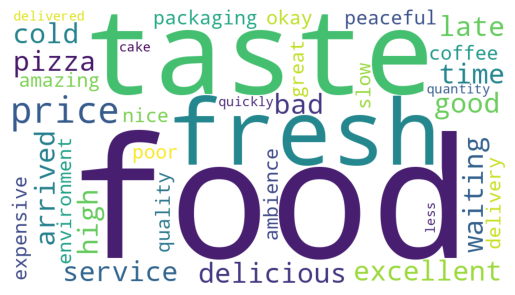

In [15]:
text = " ".join(df['clean_Review_Text'])


wordcloud = WordCloud(
    width=900,
    height=500,
    background_color='white'
).generate(text)



plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [16]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['clean_Review_Text'])
y = df['Sentiment']

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = MultinomialNB()
model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [19]:
prediction = model.predict(
    X_test
)

prediction

array(['Positive', 'Positive'], dtype='<U8')

In [20]:
accuracy = accuracy_score(
    y_test,
    prediction
)

print("Accuracy:",accuracy)

Accuracy: 0.0


In [21]:
new_review=["The food was tasty but delivery was very slow"]

clean = [clean_text(new_review[0])]
vector = tfidf.transform(clean)

model.predict(vector)

array(['Positive'], dtype='<U8')